# EDA

In [1]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv("BangalaBarta bangla_spam_sms smishing.csv")

In [48]:
# ===============================
# 3. Basic Overview
# ===============================
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)

   label                                               text
0  smish  সোনালী ব্যাংক অ্যাকাউন্টে সমস্যা হয়েছে। কল কর...
1  smish  ক্রিপ্টো বিনিয়োগে লাভবান হন! আজই শুরু করুন: h...
2  promo  স্পেশাল ডিল শেষ দিন,৩০জিবি @৩০০৳,৩০দিন! আজই না...
3  promo  ফার্নিচারে মেগা সেল! সব পণ্যে ১৫-৩০% ছাড়। আজই...
4  smish  আপনার ব্যাংক কার্ডটি অবিলম্বে আপডেট করুন। এখান...
       label                                               text
2767   smish  PLC,LIMITED.\n\nপ্রিয় আবেদনকারী, অভিনন্দন!\n\...
2768   smish  bKash অ্যাকাউন্টে ত্রুটি দেখা দিয়েছে। দ্রুত স...
2769   smish  আপনার মোবাইল নম্বরটি আইফোন জিতেছে! পুরস্কার পে...
2770   smish  আপনার ব্যাংক একাউন্ট ভেরিফাই করতে কল করুন +880...
2771  normal                           আমি যেন খুব দুঃখিত হইছি।
(2772, 2)
Index(['label', 'text'], dtype='object')


In [49]:
# ===============================
# 4. Dataset Info
# ===============================
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   2772 non-null   object
 1   text    2772 non-null   object
dtypes: object(2)
memory usage: 43.4+ KB
None


In [50]:
# ===============================
# 5. Check Missing Values
# ===============================
print(df.isnull().sum())

label    0
text     0
dtype: int64


In [51]:
# ===============================
# 6. Check Duplicate Rows
# ===============================
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1563


In [52]:
# ===============================
# 7. Class Distribution
# ===============================
print(df['label'].value_counts())

label
smish     924
promo     924
normal    924
Name: count, dtype: int64


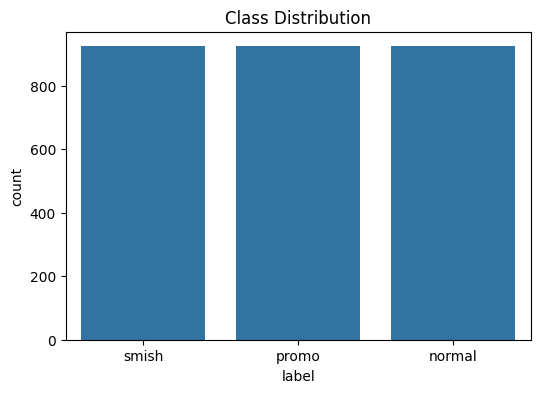

In [53]:
# ===============================
# 8. Class Distribution Plot
# ===============================
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

In [54]:
# ===============================
# 9. Text Length Analysis
# ===============================
df['char_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

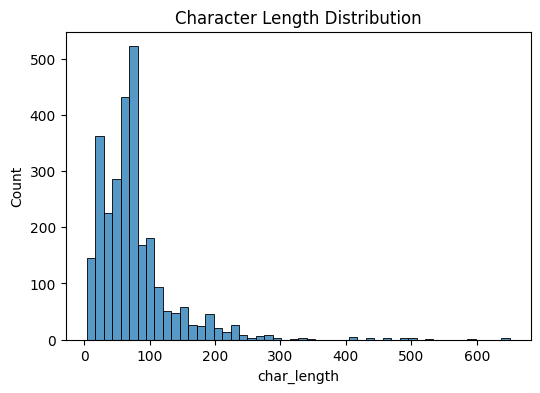

In [55]:
# ===============================
# 10. Character Length Distribution
# ===============================
plt.figure(figsize=(6,4))
sns.histplot(df['char_length'], bins=50)
plt.title("Character Length Distribution")
plt.show()

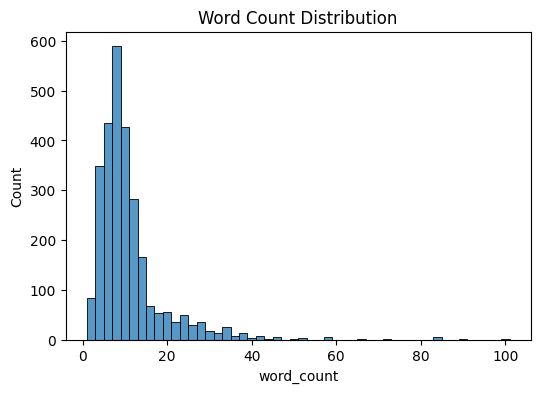

In [56]:
# ===============================
# 11. Word Count Distribution
# ===============================
plt.figure(figsize=(6,4))
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

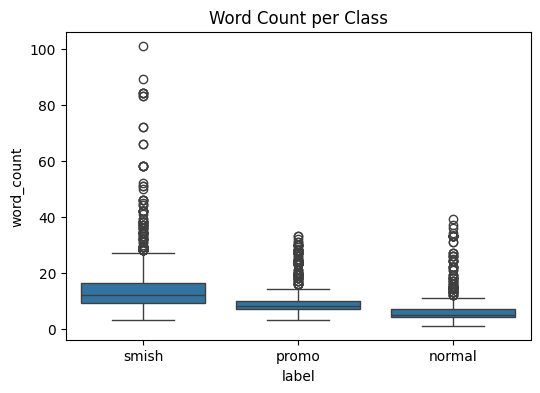

In [57]:
# ===============================
# 12. Word Count per Class
# ===============================
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count per Class")
plt.show()

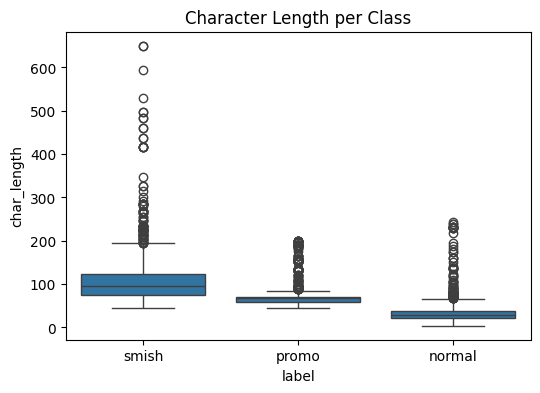

In [58]:
# ===============================
# 13. Character Length per Class
# ===============================
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='char_length', data=df)
plt.title("Character Length per Class")
plt.show()

In [59]:
# ===============================
# 14. Most Common Words
# ===============================
from collections import Counter

all_words = " ".join(df['text']).split()
word_freq = Counter(all_words)

common_words = pd.DataFrame(word_freq.most_common(20), columns=['word','count'])
print(common_words)

      word  count
0    করুন:    501
1    আপনার    490
2     টাকা    427
3     করতে    393
4       কল    286
5    ক্লিক    283
6    করুন।    225
7    এখানে    215
8     জন্য    211
9     করুন    209
10      সব    190
11      কি    189
12    থেকে    170
13     এবং    168
14      এই    168
15  ব্যাংক    161
16    তুমি    161
17   তোমার    156
18      বা    156
19     করে    156


# Text Processing

In [60]:
# ===============================
# 1. Import Libraries
# ===============================
import re
import string


In [61]:
# ===============================
# 2. Basic Text Cleaning Function
# ===============================
def clean_text(text):

    # convert to string
    text = str(text)

    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [62]:
# ===============================
# 3. Apply Cleaning
# ===============================
df["clean_text"] = df["text"].apply(clean_text)

In [63]:
# ===============================
# 4. Lowercase (if any English text exists)
# ===============================
df["clean_text"] = df["clean_text"].str.lower()

In [64]:
# ===============================
# 5. Tokenization
# ===============================
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

In [65]:
# ===============================
# 6. Word Count After Cleaning
# ===============================
df["clean_word_count"] = df["tokens"].apply(len)

In [66]:
# ===============================
# 7. Show Result
# ===============================
print(df[["text","clean_text","tokens"]].head())

                                                text  \
0  সোনালী ব্যাংক অ্যাকাউন্টে সমস্যা হয়েছে। কল কর...   
1  ক্রিপ্টো বিনিয়োগে লাভবান হন! আজই শুরু করুন: h...   
2  স্পেশাল ডিল শেষ দিন,৩০জিবি @৩০০৳,৩০দিন! আজই না...   
3  ফার্নিচারে মেগা সেল! সব পণ্যে ১৫-৩০% ছাড়। আজই...   
4  আপনার ব্যাংক কার্ডটি অবিলম্বে আপডেট করুন। এখান...   

                                          clean_text  \
0   সোনালী ব্যাংক অ্যাকাউন্টে সমস্যা হয়েছে। কল করুন   
1         ক্রিপ্টো বিনিয়োগে লাভবান হন আজই শুরু করুন   
2  স্পেশাল ডিল শেষ দিনজিবি ৳দিন আজই নাও cuttlyjwkusc   
3  ফার্নিচারে মেগা সেল সব পণ্যে ছাড়। আজই ভিজিট ক...   
4  আপনার ব্যাংক কার্ডটি অবিলম্বে আপডেট করুন। এখান...   

                                              tokens  
0  [সোনালী, ব্যাংক, অ্যাকাউন্টে, সমস্যা, হয়েছে।,...  
1  [ক্রিপ্টো, বিনিয়োগে, লাভবান, হন, আজই, শুরু, ক...  
2  [স্পেশাল, ডিল, শেষ, দিনজিবি, ৳দিন, আজই, নাও, c...  
3  [ফার্নিচারে, মেগা, সেল, সব, পণ্যে, ছাড়।, আজই,...  
4  [আপনার, ব্যাংক, কার্ডটি, অবিলম্বে, আপডেট, করুন..

# TF-IDF vectorization

In [67]:
# ===============================
# 1. Import
# ===============================
from sklearn.feature_extraction.text import TfidfVectorizer

In [68]:
# ===============================
# 2. Define TF-IDF
# ===============================
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # unigram + bigram
)

In [69]:
# ===============================
# 3. Fit and Transform
# ===============================
X = tfidf.fit_transform(df["clean_text"])

In [70]:
# ===============================
# 4. Labels
# ===============================
y = df["label"]

In [71]:
# ===============================
# 5. Shape
# ===============================
print(X.shape)
print(y.shape)

(2772, 4914)
(2772,)


# Train–Test Split

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2217, 4914)
(555, 4914)


# Naive Bayes

In [30]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9621621621621622

Classification Report:

              precision    recall  f1-score   support

      normal       0.98      0.92      0.95       185
       promo       0.98      0.99      0.99       185
       smish       0.93      0.98      0.95       185

    accuracy                           0.96       555
   macro avg       0.96      0.96      0.96       555
weighted avg       0.96      0.96      0.96       555



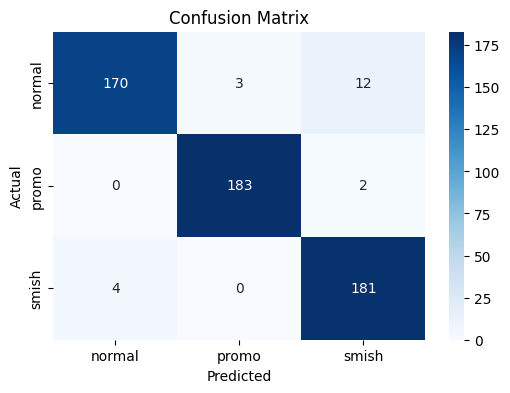

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

In [35]:
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [36]:
y_pred_lr = lr.predict(X_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9747747747747748
              precision    recall  f1-score   support

      normal       0.97      0.96      0.96       185
       promo       1.00      0.99      1.00       185
       smish       0.95      0.97      0.96       185

    accuracy                           0.97       555
   macro avg       0.97      0.97      0.97       555
weighted avg       0.97      0.97      0.97       555



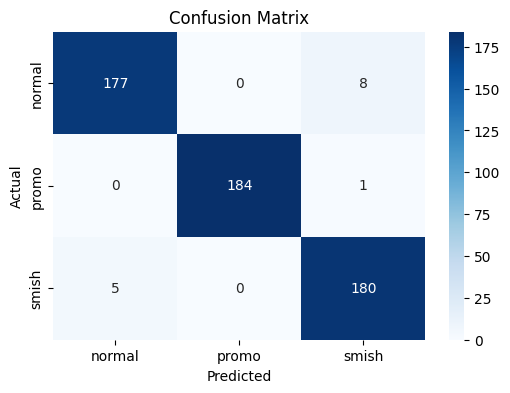

In [38]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# SVM

In [73]:
from sklearn.svm import LinearSVC

svm = LinearSVC()


In [74]:
svm.fit(X_train, y_train)

LinearSVC()

In [77]:
y_pred_svm = svm.predict(X_test)

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9819819819819819
              precision    recall  f1-score   support

      normal       0.98      0.97      0.98       185
       promo       0.99      0.99      0.99       185
       smish       0.97      0.98      0.98       185

    accuracy                           0.98       555
   macro avg       0.98      0.98      0.98       555
weighted avg       0.98      0.98      0.98       555



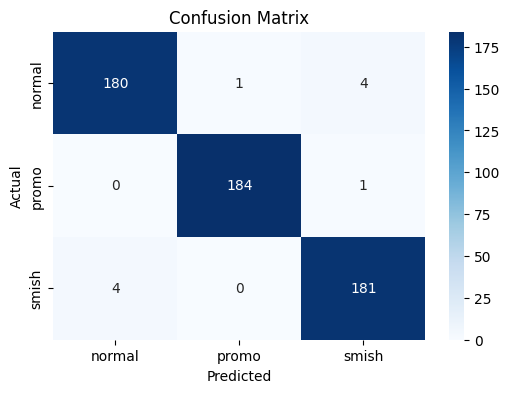

In [79]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# save_model

In [44]:
import pickle

with open("svm_smishing_model.pkl", "wb") as f:
    pickle.dump(svm, f, protocol=4)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f, protocol=4)

from google.colab import files
files.download("svm_smishing_model.pkl")
files.download("tfidf_vectorizer.pkl")

In [87]:
#msg = [
#    "সতর্কবার্তা! আপনার বিকাশ একাউন্টে গত ২৪ ঘন্টায় অস্বাভাবিক কার্যক্রম শনাক্ত করা হয়েছে। নিরাপত্তার জন্য আপনার অ্যাকাউন্টটি সাময়িকভাবে স্থগিত করা হয়েছে। অ্যাকাউন্ট পুনঃসক্রিয় করতে এবং সমস্যা সমাধান করতে, অনুগ্রহ করে নিচের লিঙ্কে গিয়ে লগইন করুন এবং যাচাই প্রক্রিয়া সম্পন্ন করুন। সতর্ক থাকুন, ২৪ ঘণ্টার মধ্যে না করলে অ্যাকাউন্ট স্থায়ীভাবে ব্লক হয়ে যেতে পারে।"
#]

msg = [
    "নতুন বছর উপলক্ষে আমাদের স্টোরে বিশেষ ছাড়! শুধুমাত্র আজকের জন্য ৫০% পর্যন্ত ছাড় পাবেন। অফারটি উপভোগ করতে এবং আপনার প্রিয় প্রোডাক্ট অর্ডার করতে এখনই আমাদের ওয়েবসাইটে ক্লিক করুন।"
]

msg_clean = [clean_text(m) for m in msg]
msg_vec = tfidf.transform(msg_clean)

prediction = svm.predict(msg_vec)

print(prediction)

['promo']


# kfold

In [80]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Deviation:", scores.std())

Fold Accuracies: [0.97297297 0.97837838 0.97111913 0.9801444  0.95848375]
Mean Accuracy: 0.9722197287540248
Std Deviation: 0.007631318669503182
